In [1]:
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from lib.layers import Dense
from lib.activations import ReLU, Sigmoid, Tanh, Softmax
from lib.losses import MSE
from lib.optimizer import SGD
from lib.network import Sequential

print("✅ Library imported successfully!")


✅ Library imported successfully!


In [2]:
# Cell 2: Gradient Checking Function
def gradient_checking(layer, X, epsilon=1e-7):
    
    print("=" * 60)
    print("GRADIENT CHECKING")
    print("=" * 60)
    
    # Forward pass
    output = layer.forward(X)
    
    # Create arbitrary gradient (simulating gradient from next layer)
    output_gradient = np.ones_like(output)
    
    # Backward pass to get analytical gradients
    layer.backward(output_gradient)
    
    if hasattr(layer, 'weights'):
        analytical_grad = layer.weights_gradient
        numerical_grad = np.zeros_like(layer.weights)
        
        # Compute numerical gradient for each weight
        print(f"Computing numerical gradients for {layer.weights.size} parameters...")
        
        it = np.nditer(layer.weights, flags=['multi_index'], op_flags=['readwrite'])
        while not it.finished:
            idx = it.multi_index
            
            old_value = layer.weights[idx]
            
            # f(x + epsilon)
            layer.weights[idx] = old_value + epsilon
            output_plus = np.sum(layer.forward(X))
            
            # f(x - epsilon)
            layer.weights[idx] = old_value - epsilon
            output_minus = np.sum(layer.forward(X))
            
            # Numerical gradient: [f(x+ε) - f(x-ε)] / (2ε)
            numerical_grad[idx] = (output_plus - output_minus) / (2 * epsilon)
            
            # Restore original value
            layer.weights[idx] = old_value
            
            it.iternext()
        
        # Compare gradients
        difference = np.linalg.norm(analytical_grad - numerical_grad) / (
            np.linalg.norm(analytical_grad) + np.linalg.norm(numerical_grad)
        )
        
        print(f"\nAnalytical Gradient (sample):\n{analytical_grad[:2, :2]}")
        print(f"\nNumerical Gradient (sample):\n{numerical_grad[:2, :2]}")
        print(f"\nRelative difference: {difference:.10f}")
        
        if difference < 1e-5:
            print("✅ Gradient check PASSED! Backpropagation is correct.")
        else:
            print("❌ Gradient check FAILED! Check your backward() implementation.")
        
        return difference
    else:
        print("Layer has no parameters to check.")

In [3]:
# Cell 3: Test Gradient Checking
print("Testing Dense Layer Gradient Checking:\n")
test_layer = Dense(3, 2)
test_input = np.random.randn(5, 3)
gradient_checking(test_layer, test_input)

Testing Dense Layer Gradient Checking:

GRADIENT CHECKING
Computing numerical gradients for 6 parameters...

Analytical Gradient (sample):
[[0.86896905 0.86896905]
 [0.73760323 0.73760323]]

Numerical Gradient (sample):
[[0.86896905 0.86896906]
 [0.73760323 0.73760323]]

Relative difference: 0.0000000004
✅ Gradient check PASSED! Backpropagation is correct.


np.float64(4.3947387703440236e-10)

In [4]:
# Cell 4: XOR Dataset
print("\n" + "=" * 60)
print("XOR PROBLEM")
print("=" * 60)

# XOR truth table
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]], dtype=float)

y_xor = np.array([[0],
                  [1],
                  [1],
                  [0]], dtype=float)

print("\nXOR Dataset:")
print("-" * 30)
for i in range(len(X_xor)):
    print(f"Input: {X_xor[i]} → Target: {y_xor[i][0]}")


XOR PROBLEM

XOR Dataset:
------------------------------
Input: [0. 0.] → Target: 0.0
Input: [0. 1.] → Target: 1.0
Input: [1. 0.] → Target: 1.0
Input: [1. 1.] → Target: 0.0


In [5]:
# Cell 5: Build and Train XOR Network
print("\n" + "=" * 60)
print("Building Network: 2 → 4 → 1")
print("=" * 60)

# Create model
model = Sequential()
model.add(Dense(2, 4))      # 2 inputs → 4 hidden neurons
model.add(Tanh())            # Tanh activation
model.add(Dense(4, 1))       # 4 hidden → 1 output
model.add(Sigmoid())         # Sigmoid output (0 to 1)

# Compile
optimizer = SGD(learning_rate=0.1)
loss = MSE()
model.compile(loss=loss, optimizer=optimizer)

print("\nModel architecture:")
print("- Input Layer: 2 neurons")
print("- Hidden Layer: 4 neurons (Tanh activation)")
print("- Output Layer: 1 neuron (Sigmoid activation)")
print(f"- Optimizer: SGD (lr={optimizer.learning_rate})")
print("- Loss: MSE")

# Train
print("\n" + "=" * 60)
print("Training...")
print("=" * 60)

history = model.fit(X_xor, y_xor, epochs=5000, verbose=True)


Building Network: 2 → 4 → 1

Model architecture:
- Input Layer: 2 neurons
- Hidden Layer: 4 neurons (Tanh activation)
- Output Layer: 1 neuron (Sigmoid activation)
- Optimizer: SGD (lr=0.1)
- Loss: MSE

Training...
Epoch 1/5000 - Loss: 0.309709
Epoch 101/5000 - Loss: 0.179032
Epoch 201/5000 - Loss: 0.128123
Epoch 301/5000 - Loss: 0.089380
Epoch 401/5000 - Loss: 0.062412
Epoch 501/5000 - Loss: 0.044921
Epoch 601/5000 - Loss: 0.033670
Epoch 701/5000 - Loss: 0.026236
Epoch 801/5000 - Loss: 0.021135
Epoch 901/5000 - Loss: 0.017497
Epoch 1001/5000 - Loss: 0.014811
Epoch 1101/5000 - Loss: 0.012769
Epoch 1201/5000 - Loss: 0.011175
Epoch 1301/5000 - Loss: 0.009904
Epoch 1401/5000 - Loss: 0.008870
Epoch 1501/5000 - Loss: 0.008017
Epoch 1601/5000 - Loss: 0.007301
Epoch 1701/5000 - Loss: 0.006695
Epoch 1801/5000 - Loss: 0.006175
Epoch 1901/5000 - Loss: 0.005725
Epoch 2001/5000 - Loss: 0.005332
Epoch 2101/5000 - Loss: 0.004986
Epoch 2201/5000 - Loss: 0.004680
Epoch 2301/5000 - Loss: 0.004407
Epoc

In [6]:
# Cell 6: XOR Results
print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

predictions = model.predict(X_xor)

print("\nPredictions:")
print("-" * 50)
print(f"{'Input':<15} {'Prediction':<15} {'Target':<10}")
print("-" * 50)

for i in range(len(X_xor)):
    pred_val = predictions[i][0]
    target_val = y_xor[i][0]
    print(f"{str(X_xor[i]):<15} {pred_val:>8.4f}       {target_val:>8.0f}")

# Binary accuracy
predictions_binary = (predictions > 0.5).astype(int)
accuracy = np.mean(predictions_binary == y_xor)
print(f"\nBinary Accuracy: {accuracy * 100:.2f}%")



FINAL RESULTS

Predictions:
--------------------------------------------------
Input           Prediction      Target    
--------------------------------------------------
[0. 0.]           0.0205              0
[0. 1.]           0.9571              1
[1. 0.]           0.9581              1
[1. 1.]           0.0505              0

Binary Accuracy: 100.00%


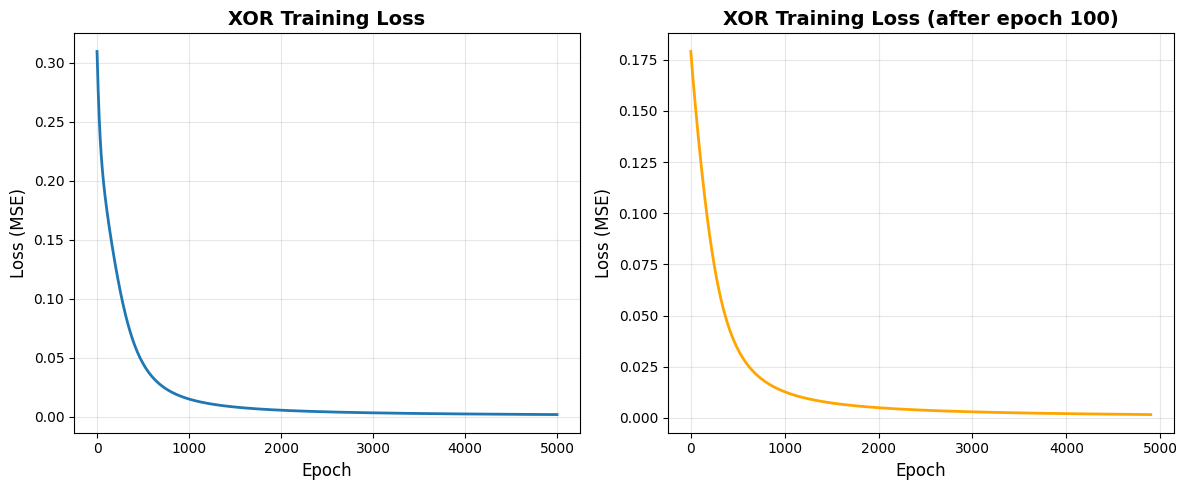


✅ Part 1 Complete! Your library works correctly.


In [7]:
# Cell 7: Plot Training Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('XOR Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['loss'][100:], linewidth=2, color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('XOR Training Loss (after epoch 100)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Part 1 Complete! Your library works correctly.")